# W3D4 — The Same Network, the PyTorch Way — Lab

**Week 3 · Day 4 · Deep Learning & Neural Networks** · Lab

Same data, same architecture, same starting weights — and every hand-built piece swapped for the one
the library ships.

Yesterday's network was bare tensors: a dict of four weights, a `forward` function, a `bce_loss`, and a
loop that called `loss.backward()` and then updated each tensor by hand under `torch.no_grad()`.
Autograd already did the hard part. Today you replace everything around it with the objects every
PyTorch codebase is built from — `nn.Linear` and `nn.Module`, `nn.BCELoss`, `torch.optim.SGD`,
`DataLoader` — load yesterday's exact starting weights, and watch the two loss sequences agree to
fourteen decimal places. Not "close". Identical.

Then count what changed, and find that almost nothing was removed. It was renamed, and packaged.

Four things, in order:

- **`nn.Linear` is your `X @ W1 + b1`** — the same numbers stored transposed, and the lecture's
  `−0.1360` and `−0.0544` now arriving in a layer's own `.grad`.
- **`nn.Module`, `Dataset`, `DataLoader`** — the three objects that replace your dict of tensors and
  your loose functions.
- **The five-line loop**, run twice: once full-batch, matching yesterday exactly, and once with a
  `DataLoader` handing you 32 rows at a time.
- **The bug on purpose.** Delete `optimizer.zero_grad()` — yesterday's `p.grad = None` — retrain, and
  watch the curve do the thing slide 54 described. Then put it back.

You leave with `torch_net_history.parquet`.

**Time budget:** ~115 minutes. Sections 1–2 are the lab; Section 3 is a stretch you may finish at home.

<div dir="rtl" align="right">

# الأسبوع ٣ اليوم ٤ — الشبكة نفسها، على طريقة PyTorch

**الأسبوع ٣ · اليوم ٤ · التعلّم العميق والشبكات العصبية** · معمل عملي

البيانات نفسها والمعمارية نفسها والأوزان الابتدائية نفسها — وكل قطعة بنيتها بيدك تُستبدل بالتي تأتي
بها المكتبة.

كانت شبكة الأمس تنسورات عارية: قاموسًا من أربعة أوزان، ودالة `forward`، و`bce_loss`، وحلقة تنادي
`loss.backward()` ثم تُحدّث كل تنسور بيدك داخل `torch.no_grad()`. وقد تولّى الاشتقاق التلقائي الجزء
الصعب أصلًا. واليوم تستبدل كل ما حوله بالكائنات التي تُبنى منها كل شيفرة PyTorch — `nn.Linear`
و`nn.Module` و`nn.BCELoss` و`torch.optim.SGD` و`DataLoader` — وتُحمّل أوزان الأمس الابتدائية بالضبط،
وترى متتاليتَي الخسارة تتوافقان إلى أربع عشرة خانة عشرية. لا «قريبتان» بل مطابقتان.

ثم تعدّ ما تغيّر، فتجد أن شيئًا تقريبًا لم يُحذف، بل أُعيدت تسميته وتغليفه.

وأربعة أمور بالترتيب:

- **`nn.Linear` هو `X @ W1 + b1` عندك** — الأرقام نفسها مخزّنةً منقولةً، و`−0.1360` و`−0.0544` من
  المحاضرة يصلان الآن إلى `.grad` في الطبقة نفسها.
- **`nn.Module` و`Dataset` و`DataLoader`** — الكائنات الثلاثة التي تحلّ محلّ قاموس تنسوراتك ودوالك
  المتفرّقة.
- **حلقة الأسطر الخمسة** مشغّلة مرتين: مرة بدفعة كاملة تطابق الأمس تمامًا، ومرة بـ `DataLoader`
  يناولك ٣٢ صفًا في المرة.
- **العيب عن قصد.** احذف `optimizer.zero_grad()` — وهو `p.grad = None` بالأمس — وأعِد التدريب وشاهد
  المنحنى يفعل ما وصفته الشريحة ٥٤. ثم أعِده.

ستخرج بملف `torch_net_history.parquet`.

**الزمن المتوقّع:** نحو ١١٥ دقيقة. القسمان الأول والثاني هما المعمل، والقسم الثالث إضافي يمكن إكماله في المنزل.

</div>

> **This is your lab notebook.** Work through the hints — they tell you what to do and where
> to look, not what to type. Stuck for more than ten minutes on one task? Open the `_guided`
> version. That is not cheating; sitting stuck in silence is the only mistake. The full
> solution is released at the end of the day.

<div dir="rtl" align="right">

> **هذا دفتر المعمل الخاص بك.** اعمل وفق الإرشادات — فهي تخبرك بما يجب فعله وأين تبحث، لا بما
> تكتبه حرفيًا. إذا توقّفت أكثر من عشر دقائق عند مهمة واحدة فافتح نسخة `_guided`؛ هذا ليس غشًّا،
> والخطأ الوحيد هو أن تبقى متوقّفًا بصمت. ويُنشر الحل الكامل في نهاية اليوم.

</div>

## Learning objectives

By the end of this lab you can:

- Say what `nn.Linear` computes, and why its weight matrix is transposed relative to yours.
- Define a network as an `nn.Module`, enumerate its parameters, and find a gradient on a named layer.
- Load specific weights into a model under `torch.no_grad()`.
- Write the five-line training loop from memory, in the right order, and say which line of
  yesterday's loop each one replaced.
- Say what `optimizer.zero_grad()` prevents, having removed it and looked at the damage.
- Wrap data in a `TensorDataset` and iterate it with a `DataLoader`, and explain what shuffling and
  batching change about the gradient.
- State honestly which lines a library removed and which it merely renamed.

<div dir="rtl" align="right">

## أهداف التعلّم

بنهاية هذا المعمل ستكون قادرًا على:

- بيان ما يحسبه `nn.Linear`، ولماذا تكون مصفوفة أوزانه منقولةً مقارنةً بمصفوفتك.
- تعريف شبكة كـ `nn.Module` وتعداد معاملاتها، وإيجاد اشتقاق على طبقة مُسمّاة.
- تحميل أوزان محدّدة في نموذج داخل `torch.no_grad()`.
- كتابة حلقة التدريب ذات الأسطر الخمسة من الذاكرة وبالترتيب الصحيح، وبيان أي سطر من حلقة الأمس حلّ
  كلٌّ منها محلّه.
- بيان ما يمنعه `optimizer.zero_grad()` بعد أن حذفته ونظرت في الضرر.
- لفّ البيانات في `TensorDataset` والمرور عليها بـ `DataLoader`، وشرح ما يغيّره الخلط والتقسيم إلى
  دفعات في الاشتقاق.
- قول أيّ الأسطر حذفتها المكتبة وأيّها أعادت تسميتها فقط، قولًا صادقًا.

</div>


## About the data

**Dataset:** `moons_toy` — 500 rows × 3 columns, the same file as Tuesday and Wednesday, CC0

Nothing about the data changes today, and that is the point: the only way to compare two
implementations honestly is to change **one** thing, and today the one thing is how the network is
written.

You also load two artefacts from yesterday:

- **`tensor_net_params.pt`** — the weights yesterday's run **started** from. These go into today's
  model directly. Without them the two runs would start in different places and any agreement between
  them would be a coincidence.
- **`tensor_net_history.parquet`** — yesterday's 2,000 recorded losses, to plot against today's.

If you did not finish yesterday, `load_artefact` falls back to the reference copies in
`shared/solutions_cache/` and prints a note. You are not blocked.

**Watch out:** the setup keeps Tuesday's `torch.set_default_dtype(torch.float64)`, so every
`nn.Linear` you create today is 64-bit too, and today's run can match yesterday's to the last decimal.
Drop that line and the layers come out `float32`: nothing errors, the two runs simply stop agreeing
past about the seventh decimal. From next week `float32` is what you want — it is the default for a
reason, and it is what GPUs are built for.

<div dir="rtl" align="right">

## عن البيانات

**مجموعة البيانات:** `moons_toy` — ٥٠٠ صف × ٣ أعمدة، الملف نفسه يوم الثلاثاء والأربعاء، رخصة CC0

لا شيء في البيانات يتغيّر اليوم، وهذا هو المقصود: فالطريق الوحيد لمقارنة تنفيذين مقارنةً صادقة هو
تغيير شيء **واحد**، والشيء الواحد اليوم هو طريقة كتابة الشبكة.

وتُحمّل أيضًا أثرين من الأمس:

- **`tensor_net_params.pt`** وفيه الأوزان التي **بدأ** منها تشغيل الأمس. وتدخل هذه في نموذج اليوم
  مباشرة. ولولاها لبدأ التشغيلان من موضعين مختلفين ولكان أي توافق بينهما مصادفة.
- **`tensor_net_history.parquet`** وفيه خسائر الأمس الألفان لترسمها مقابل خسائر اليوم.

وإن لم تُكمل الأمس فإن `load_artefact` ترجع إلى النسخ المرجعية في `shared/solutions_cache/` وتطبع
ملاحظة بذلك، فأنت غير متعطّل.

**انتبه:** يُبقي الإعداد على `torch.set_default_dtype(torch.float64)` من يوم الثلاثاء، فكل `nn.Linear`
تُنشئه اليوم بـ ٦٤ بتًا أيضًا، ويستطيع تشغيل اليوم مطابقة تشغيل الأمس إلى آخر خانة. وإن حذفت ذلك السطر
خرجت الطبقات بـ `float32`: فلا يظهر خطأ، بل يكفّ التشغيلان عن التوافق بعد الخانة السابعة تقريبًا. ومن
الأسبوع القادم `float32` هو ما تريده — فهو الافتراضي لسبب، وهو ما صُنعت له المعالجات الرسومية.

</div>


## Setup

Run the cell below first. It loads the data and yesterday's two artefacts, and prints the device you
are on.

<div dir="rtl" align="right">

## الإعداد

شغّل الخليّة أدناه أولًا. تُحمّل البيانات وأثرَي الأمس، وتطبع الجهاز الذي تعمل عليه.

</div>


In [1]:
# === AIEP portable setup — works locally (Miniconda + uv) and on Google Colab ===============
try:
    import aiep
except ImportError:
    import subprocess, sys
    from pathlib import Path
    _local = next((p / "shared" for p in [Path.cwd(), *Path.cwd().parents]
                   if (p / "shared" / "aiep").is_dir()), None)
    if _local:
        sys.path.insert(0, str(_local))
    else:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q",
                               "git+https://github.com/0xRush/AIEP_Olo_student.git#subdirectory=shared"])
    import aiep

from aiep.env import ensure, seed_everything, versions, device
from aiep.data import get_dataset, load_artefact
from aiep.paths import ARTEFACT_DIR
from aiep.checks import check, report

ensure("torch", "matplotlib", "pyarrow")
seed_everything(42)

import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from aiep.viz import use_course_style, PALETTE
use_course_style()

# 64-bit, as on Tuesday and Wednesday, so today's run can match yesterday's exactly.
torch.set_default_dtype(torch.float64)

moons = pd.read_parquet(get_dataset("moons_toy"))
X = torch.tensor(moons[["x1", "x2"]].to_numpy())
y = torch.tensor(moons["label"].to_numpy(), dtype=torch.float64).reshape(-1, 1)

# Yesterday's run: the weights it started from, and the loss it recorded.
saved = torch.load(load_artefact("tensor_net_params.pt"))
INIT = saved["init"]
yesterday_history = pd.read_parquet(load_artefact("tensor_net_history.parquet"))

N_IN, N_HIDDEN, N_OUT = 2, 8, 1
ITERATIONS, LR = 2000, 1.0
DEVICE = device()

print(f"X {tuple(X.shape)} | y {tuple(y.shape)} | device: {DEVICE}")
print(f"yesterday's starting weights: "
      f"{', '.join(f'{k} {tuple(v.shape)}' for k, v in INIT.items())}")
print(f"yesterday's loss: {yesterday_history.iloc[0]['loss']:.6f} -> "
      f"{yesterday_history.iloc[-1]['loss']:.6f} over {len(yesterday_history):,} iterations")
print("\n", versions())

📁 moons_toy: using cached file at C:\Users\Fajer\OneDrive\Documents\GitHub\AIEP_Olo_student\shared\data_cache\moons_toy.parquet
ℹ️  Using the reference copy of tensor_net_params.pt from solutions_cache (you don't have a local one yet).
   نستخدم النسخة المرجعية من tensor_net_params.pt لعدم وجود نسخة محلية لديك.
ℹ️  Using the reference copy of tensor_net_history.parquet from solutions_cache (you don't have a local one yet).
   نستخدم النسخة المرجعية من tensor_net_history.parquet لعدم وجود نسخة محلية لديك.
X (500, 2) | y (500, 1) | device: cpu
yesterday's starting weights: W1 (2, 8), b1 (8,), W2 (8, 1), b2 (1,)
yesterday's loss: 0.517694 -> 0.038027 over 2,000 iterations

 python 3.12.10 | numpy 2.0.2 | pandas 3.0.6 | scikit-learn 1.9.1 | torch 2.14.1+cpu


## Section 1 — Warm-up: a layer, two ways  (≈25 min)

Everything in this section already works.

`nn.Linear(2, 8)` is not a new idea. It is a box holding two tensors — a weight and a bias — and a
`forward` that computes `x @ weight.T + bias`. That is Tuesday's first line, with the weight stored
the other way round.

The cell below makes one, copies yesterday's `W1` and `b1` into it, and runs all 500 rows through
both: the layer, and your own `X @ W1 + b1`. Then the same comparison for the ReLU, the sigmoid and the
loss. If any library piece did something other than what yours did, it shows up here as a number
that is not zero.

<div dir="rtl" align="right">

## القسم الأول — التهيئة: طبقة بطريقتين (نحو ٢٥ دقيقة)

كل ما في هذا القسم يعمل أصلًا.

ليس `nn.Linear(2, 8)` فكرة جديدة. إنه صندوق يحمل تنسورين — وزنًا وانحيازًا — ودالة `forward` تحسب
`x @ weight.T + bias`. وهذا هو السطر الأول يوم الثلاثاء، والوزن مخزّن بالاتجاه المعاكس.

وتصنع الخليّة أدناه واحدًا، وتنسخ فيه `W1` و`b1` من الأمس، وتمرّر الصفوف الخمسمئة كلها في الاثنين:
الطبقة، و`X @ W1 + b1` عندك. ثم المقارنة نفسها لـ ReLU والدالة السينية والخسارة. فإن فعلت أي قطعة من
المكتبة شيئًا غير ما فعلته قطعتك، ظهر هنا رقمًا ليس صفرًا.

</div>


In [2]:
layer = nn.Linear(2, 8)
print(f"a fresh nn.Linear(2, 8): weight {tuple(layer.weight.shape)}, "
      f"bias {tuple(layer.bias.shape)}, dtype {layer.weight.dtype}")
print(f"its tensors already track gradients: requires_grad={layer.weight.requires_grad}")

with torch.no_grad():
    layer.weight.copy_(INIT["W1"].T)     # yours was (2, 8); the layer stores (8, 2)
    layer.bias.copy_(INIT["b1"])

by_hand = X @ INIT["W1"] + INIT["b1"]
by_layer = layer(X)
print(f"\nX @ W1 + b1  vs  layer(X), all 500 rows: largest difference "
      f"{(by_hand - by_layer).abs().max().item():.1e}")

z = torch.linspace(-3, 3, 7)
print(f"torch.clamp(z, min=0)  vs  torch.relu(z): identical "
      f"{torch.equal(torch.clamp(z, min=0), torch.relu(z))}")
print(f"1 / (1 + exp(-z))  vs  torch.sigmoid(z): largest difference "
      f"{(1 / (1 + torch.exp(-z)) - torch.sigmoid(z)).abs().max().item():.1e}")

p, t = torch.tensor([[0.9], [0.1]]), torch.tensor([[1.0], [1.0]])
by_hand_bce = -torch.mean(t * torch.log(p) + (1 - t) * torch.log(1 - p))
print(f"Wednesday's bce_loss  vs  nn.BCELoss(): "
      f"{by_hand_bce.item():.10f} vs {nn.BCELoss()(p, t).item():.10f}")
print("\nevery piece of today's model is a piece of yesterday's, under a library name")

a fresh nn.Linear(2, 8): weight (8, 2), bias (8,), dtype torch.float64
its tensors already track gradients: requires_grad=True

X @ W1 + b1  vs  layer(X), all 500 rows: largest difference 0.0e+00
torch.clamp(z, min=0)  vs  torch.relu(z): identical True
1 / (1 + exp(-z))  vs  torch.sigmoid(z): largest difference 0.0e+00
Wednesday's bce_loss  vs  nn.BCELoss(): 1.2039728043 vs 1.2039728043

every piece of today's model is a piece of yesterday's, under a library name


### Task 1.1 — the lecture's network, as layers

On Wednesday you got `∂L/∂W2 = [−0.1360, −0.0544]` twice: once by nudging, and once from
`loss.backward()` on four bare tensors.

Here is the same network built from layers — `nn.Linear(2, 2)`, a ReLU, `nn.Linear(2, 1)`, a
sigmoid — with the lecture's six weights copied in. Run the forward pass and call `loss.backward()`.

The call is the same as yesterday. What changed is where the answer lives: not in a tensor you made
and named, but in `.grad` on the layer's own parameter — `lecture[2].weight.grad`, shape `(1, 2)`,
because that is how the layer stores `W2`.

<div dir="rtl" align="right">

### المهمة ١٫١ — شبكة المحاضرة، طبقاتٍ

حصلت يوم الأربعاء على `∂L/∂W2 = [−0.1360, −0.0544]` مرتين: مرة بالتحريك، ومرة من `loss.backward()`
على أربعة تنسورات عارية.

وهذه هي الشبكة نفسها مبنيّةً من طبقات — `nn.Linear(2, 2)` ثم ReLU ثم `nn.Linear(2, 1)` ثم الدالة
السينية — ومنسوخ فيها أوزان المحاضرة الستة. شغّل المرور الأمامي ثم نادِ `loss.backward()`.

والنداء هو نفسه بالأمس. والذي تغيّر هو موضع الجواب: ليس في تنسور صنعته وسمّيته، بل في `.grad` على
معامل الطبقة نفسها — `lecture[2].weight.grad` بشكل `(1, 2)`، لأن الطبقة تخزّن `W2` هكذا.

</div>


In [3]:
lecture = nn.Sequential(nn.Linear(2, 2), nn.ReLU(), nn.Linear(2, 1), nn.Sigmoid())
with torch.no_grad():
    lecture[0].weight.copy_(torch.tensor([[0.5, -0.5], [1.0, 0.5]]).T)
    lecture[0].bias.copy_(torch.tensor([0.0, 0.5]))
    lecture[2].weight.copy_(torch.tensor([[1.0], [-1.0]]).T)
    lecture[2].bias.copy_(torch.tensor([0.0]))

x_one = torch.tensor([[1.0, 2.0]])
out = lecture(x_one)
loss = ((out - 1.0) ** 2).mean()

print(f"hidden layer: {lecture[1](lecture[0](x_one))[0].tolist()}   <- Tuesday's [2.5, 1.0]")
print(f"output:       {out.item():.4f}       <- Tuesday's 0.8176")
print(f"loss:         {loss.item():.4f}       <- Wednesday's 0.0333")

loss.backward()

W2_grad = lecture[2].weight.grad
print(f"\nlecture[2].weight.grad = {W2_grad.round(decimals=4).tolist()}   "
      f"shape {tuple(W2_grad.shape)}")
print(f"Wednesday's pair:        [[-0.136, -0.0544]]")
print(f"agree to four decimals:  "
      f"{torch.allclose(W2_grad, torch.tensor([[-0.1360, -0.0544]]), atol=5e-5)}")

print(f"\nevery parameter, found by name — nobody had to mark any of them:")
for name, parameter in lecture.named_parameters():
    print(f"  {name:<10} {str(tuple(parameter.shape)):<8} "
          f"grad {parameter.grad.round(decimals=4).tolist()}")

hidden layer: [2.5, 1.0]   <- Tuesday's [2.5, 1.0]
output:       0.8176       <- Tuesday's 0.8176
loss:         0.0333       <- Wednesday's 0.0333

lecture[2].weight.grad = [[-0.136, -0.0544]]   shape (1, 2)
Wednesday's pair:        [[-0.136, -0.0544]]
agree to four decimals:  True

every parameter, found by name — nobody had to mark any of them:
  0.weight   (2, 2)   grad [[-0.0544, -0.1088], [0.0544, 0.1088]]
  0.bias     (2,)     grad [-0.0544, 0.0544]
  2.weight   (1, 2)   grad [[-0.136, -0.0544]]
  2.bias     (1,)     grad [-0.0544]


Same call, same numbers — and the gradient now has an address.

**Autograd did nothing new.** It walked back through the same graph it walked yesterday: two matrix
products, two additions, a ReLU and a sigmoid. `nn.Linear` just built the `@` and the `+` for you.

**What is new is the bookkeeping.** Yesterday you had to keep `W2` as a key in your own dict and
remember to call `requires_grad_` on it. Today the layer made its parameters itself, marked them
itself, and `named_parameters()` lists every one of them. That list is exactly what an optimiser is
handed in task 2.3 — which is why you will never write `for p in params.values()` again.

<div dir="rtl" align="right">

النداء نفسه والأرقام نفسها — وصار للاشتقاق عنوان.

**لم يفعل الاشتقاق التلقائي شيئًا جديدًا.** فقد رجع في المخطّط نفسه الذي رجع فيه بالأمس: ضربان
مصفوفيّان وجمعان وReLU ودالة سينية. و`nn.Linear` بنى لك `@` و`+` فحسب.

**والجديد هو مسك الدفاتر.** فبالأمس كان عليك أن تحفظ `W2` مفتاحًا في قاموسك وأن تتذكّر نداء
`requires_grad_` عليه. واليوم صنعت الطبقة معاملاتها بنفسها وعلّمتها بنفسها، و`named_parameters()` يسرد
كل واحد منها. وتلك القائمة هي بالضبط ما يُناوَله المُحسِّن في المهمة ٢٫٣ — ولهذا لن تكتب
`for p in params.values()` مرة أخرى.

</div>


## Section 2 — Core: six tasks  (≈60 min)

1. `TensorDataset` and `DataLoader`, and what a batch actually looks like.
2. The network as an `nn.Module`, loaded with yesterday's exact starting weights.
3. The five-line loop, full-batch, for the same 2,000 iterations.
4. Both loss curves on one figure, and the size of the disagreement.
5. Count what changed, and name what replaced each line of yesterday's loop.
6. Delete `optimizer.zero_grad()` on purpose and look at the damage.

<div dir="rtl" align="right">

## القسم الثاني — الأساسي: ست مهام (نحو ٦٠ دقيقة)

١. `TensorDataset` و`DataLoader`، وكيف تبدو الدفعة فعلًا.
٢. الشبكة كـ `nn.Module` مُحمَّلة بأوزان الأمس الابتدائية بالضبط.
٣. حلقة الأسطر الخمسة بدفعة كاملة للتكرارات الألفين نفسها.
٤. منحنيا الخسارة في شكل واحد، وحجم الاختلاف.
٥. عُدّ ما تغيّر، وسمِّ ما حلّ محلّ كل سطر من حلقة الأمس.
٦. احذف `optimizer.zero_grad()` عن قصد وانظر في الضرر.

</div>


### Task 2.1 — the conveyor belt

`TensorDataset` pairs your features with your labels and answers two questions: how many items are
there, and what is item *i*. That is the entire `Dataset` interface.

`DataLoader` wraps it and hands the training loop batches, shuffled. Set `batch_size=32` and iterate
once to see what comes out.

500 does not divide by 32. The last batch has **20** rows, and PyTorch hands it to you rather than
dropping it — which is correct, and also means any code of yours that assumes a fixed batch size is
wrong once per epoch. Print the sizes and see it.

<div dir="rtl" align="right">

### المهمة ٢٫١ — الحزام الناقل

يُزاوج `TensorDataset` خصائصك مع تصنيفاتك، ويجيب عن سؤالين: كم عدد العناصر، وما العنصر رقم *i*. وهذه
هي واجهة `Dataset` كلها.

ويلفّه `DataLoader` ويناول حلقة التدريب دفعات مخلوطة. اضبط `batch_size=32` ومُرّ مرة واحدة لترى ما
يخرج.

و٥٠٠ لا تقبل القسمة على ٣٢. فالدفعة الأخيرة فيها **٢٠** صفًا، ويناولك PyTorch إياها ولا يرميها — وهذا
صحيح، ويعني أيضًا أن أي شيفرة عندك تفترض حجم دفعة ثابتًا تكون خطأً مرة في كل حقبة. اطبع الأحجام
وانظر.

</div>


In [4]:
# ────────────────────────────────────────────────────────────────────
# 1) X and y are already float64 tensors from the setup cell: TensorDataset(X, y).
# 2) DataLoader(dataset, batch_size=32, shuffle=True). Pass a generator with a
#    manual seed if you want the shuffle to be reproducible.
# 3) Iterate once, collect the batch sizes, and print the first batch's shape and
#    the last batch's shape. They are not the same.
# Search: "pytorch TensorDataset DataLoader batch_size shuffle"
# https://pytorch.org/docs/stable/data.html
#
# ١) `X` و`y` تنسوران بـ `float64` أصلًا من خليّة الإعداد: `TensorDataset(X, y)`.
# ٢) `DataLoader(dataset, batch_size=32, shuffle=True)`. ومرّر `generator` ببذرة
#    ثابتة إن أردت الخلط قابلًا لإعادة الإنتاج.
# ٣) مُرّ مرة واحدة واجمع أحجام الدفعات، واطبع شكل أول دفعة وشكل آخر دفعة. وهما
#    ليسا متساويين.
# ابحث عن: "pytorch TensorDataset DataLoader batch_size shuffle"
# ────────────────────────────────────────────────────────────────────

BATCH_SIZE = 32
# TODO: Build a TensorDataset and a shuffled DataLoader with batch_size=32.
dataset = TensorDataset(X, y)
loader = DataLoader(dataset,
                    batch_size=BATCH_SIZE,
                    shuffle=True,
                    generator=torch.Generator().manual_seed(42))

# TODO: Iterate once and collect the shape of every batch.
batch_shapes = []
for xb, yb in loader:
    batch_shapes.append(xb.shape)

print(f"{len(dataset)} rows, batch_size {BATCH_SIZE} -> {len(batch_shapes)} batches")
print(f"first batch: {batch_shapes[0]}")
print(f"last batch:  {batch_shapes[-1]}   <- 500 = 15 x 32 + 20")
print(f"every row appears exactly once per epoch: "
      f"{sum(shape[0] for shape in batch_shapes) == len(dataset)}")

500 rows, batch_size 32 -> 16 batches
first batch: torch.Size([32, 2])
last batch:  torch.Size([20, 2])   <- 500 = 15 x 32 + 20
every row appears exactly once per epoch: True


### Task 2.2 — the network as an object

Yesterday your network was a dict of tensors and a function that knew how to use it. Ask that dict
"what are your parameters" and there is no answer — you would have to go and collect them, by name,
correctly, every time you wanted to save it, move it or optimise it.

`nn.Module` is a box that knows what is inside it. `__init__` declares the layers; `forward` says how
they compose; and because the layers were declared, `.parameters()`, `.to(device)` and
`.state_dict()` all become possible.

Then the part that makes today's comparison honest: **load yesterday's starting weights into it.**

`nn.Linear(2, 8)` stores its weight as `(out_features, in_features)` — `(8, 2)` — because it computes
`x @ W.T + b`. Yours was `(2, 8)`. So the numbers are the same numbers, transposed. Get this backwards
and nothing errors: `(2, 8)` and `(8, 2)` are both valid shapes for *something*, and you will train a
network that is quietly not yours.

<div dir="rtl" align="right">

### المهمة ٢٫٢ — الشبكة ككائن

كانت شبكتك بالأمس قاموس تنسورات ودالةً تعرف كيف تستخدمه. واسأل ذلك القاموس «ما معاملاتك» فلا
جواب — بل عليك أن تذهب وتجمعها بالاسم وبصواب في كل مرة تريد حفظها أو نقلها أو تحسينها.

و`nn.Module` صندوق يعرف ما بداخله. فـ `__init__` تُعلن الطبقات، و`forward` تقول كيف تتركّب، ولأن
الطبقات أُعلنت صار `.parameters()` و`.to(device)` و`.state_dict()` ممكنة.

ثم الجزء الذي يجعل مقارنة اليوم صادقة: **حمّل أوزان الأمس الابتدائية فيه.**

يخزّن `nn.Linear(2, 8)` وزنه بالشكل (`out_features`, `in_features`) أي `(8, 2)`، لأنه يحسب
`x @ W.T + b`. وشكلك كان `(2, 8)`. فالأرقام هي الأرقام نفسها منقولةً. وإن عكستها لم يُخرِج شيء خطأً:
فـ `(2, 8)` و`(8, 2)` شكلان صحيحان لـ**شيء ما**، وستدرّب شبكة ليست شبكتك بهدوء.

</div>


In [5]:
# ────────────────────────────────────────────────────────────────────
# 1) Subclass nn.Module. In __init__ call super().__init__() first, then declare
#    two nn.Linear layers: (2, 8) and (8, 1).
# 2) forward applies relu after the first and sigmoid after the second — the same
#    two activations as yesterday's forward().
# 3) No .double() needed: the default dtype is already float64, so the layers are.
# 4) Copy INIT's weights in under torch.no_grad(), and remember the transpose:
#    nn.Linear's weight is (out, in) and yours was (in, out).
# Search: "pytorch nn.Module custom network load weights no_grad copy_"
# https://pytorch.org/docs/stable/generated/torch.nn.Linear.html
#
# ١) ورِّث من `nn.Module`. ونادِ `super().__init__()` أولًا في `__init__`، ثم أعلن
#    طبقتَي `nn.Linear`: `(2, 8)` و`(8, 1)`.
# ٢) تطبّق `forward` دالة `relu` بعد الأولى والدالة السينية بعد الثانية — وهما
#    التنشيطان نفساهما في `forward()` بالأمس.
# ٣) لا حاجة إلى `.double()`: فالنوع الافتراضي `float64` أصلًا، وكذلك الطبقات.
# ٤) انسخ أوزان `INIT` داخل `torch.no_grad()`، وتذكّر النقل: وزن `nn.Linear`
#    شكله (out, in) وشكلك كان (in, out).
# ابحث عن: "pytorch nn.Module custom network load weights no_grad copy_"
# ────────────────────────────────────────────────────────────────────

# TODO: Define the 2-8-1 network as an nn.Module.
class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.sigmoid(self.fc2(x))
        return x

model = Net()

# TODO: Load yesterday's starting weights into the model — mind the transpose.
with torch.no_grad():
    model.fc1.weight.copy_(INIT["W1"].T)
    model.fc1.bias.copy_(INIT["b1"])
    model.fc2.weight.copy_(INIT["W2"].T)
    model.fc2.bias.copy_(INIT["b2"])

print(f"parameter shapes: {[tuple(p.shape) for p in model.parameters()]}")
n_parameters = sum(p.numel() for p in model.parameters())
print(f"parameters: {n_parameters}   <- Tuesday's hand count for 2-8-1")
print(f"\nyour W1 was {tuple(INIT['W1'].shape)}, "
      f"nn.Linear stores {tuple(model.fc1.weight.shape)} — the same numbers, "
      f"transposed: {torch.equal(model.fc1.weight.detach().T, INIT['W1'])}")
print(f"\nthe untrained model on row 0: {model(X[:1]).item():.10f}")

parameter shapes: [(8, 2), (8,), (1, 8), (1,)]
parameters: 33   <- Tuesday's hand count for 2-8-1

your W1 was (2, 8), nn.Linear stores (8, 2) — the same numbers, transposed: True

the untrained model on row 0: 0.7431985306


### Task 2.3 — the five lines

```python
optimizer.zero_grad()      # yesterday: p.grad = None, for every p
out = model(x)             # yesterday: forward(params, X)
loss = criterion(out, y)   # yesterday: bce_loss(y, output)
loss.backward()            # yesterday: loss.backward() — the same line
optimizer.step()           # yesterday: with torch.no_grad(): p -= LR * p.grad
```

That is the whole of training, and it is the same five statements for every model in weeks 4 to 7.
Each one is a line you already wrote; the comments say which.

Run it full-batch — all 500 rows per step, `SGD` at `lr=1.0`, `BCELoss`, 2,000 iterations. Those are
yesterday's settings exactly, because the point of this run is not to train well, it is to train
**identically**.

Record the loss each iteration.

<div dir="rtl" align="right">

### المهمة ٢٫٣ — الأسطر الخمسة

```python
optimizer.zero_grad()      # بالأمس: p.grad = None لكل p
out = model(x)             # بالأمس: forward(params, X)
loss = criterion(out, y)   # بالأمس: bce_loss(y, output)
loss.backward()            # بالأمس: loss.backward() — السطر نفسه
optimizer.step()           # بالأمس: with torch.no_grad(): p -= LR * p.grad
```

هذا هو التدريب كله، وهي الجُمل الخمس نفسها لكل نموذج في الأسابيع من الرابع إلى السابع. وكل واحدة
منها سطر كتبته من قبل، والتعليقات تقول أيّها.

شغّلها بدفعة كاملة — الصفوف الخمسمئة كلها في كل خطوة، و`SGD` بـ `lr=1.0`، و`BCELoss`، وألفا تكرار.
وهذه إعدادات الأمس بالضبط، لأن مقصود هذا التشغيل ليس التدريب الجيد بل التدريب **المطابق**.

وسجّل الخسارة في كل تكرار.

</div>


In [6]:
# ────────────────────────────────────────────────────────────────────
# 1) torch.optim.SGD(model.parameters(), lr=LR) and nn.BCELoss(). BCELoss expects
#    probabilities, which is what your sigmoid output already is.
# 2) The five statements, in order, inside a loop over range(ITERATIONS). Full
#    batch means you pass the whole X, not a DataLoader batch.
# 3) Record loss.item() each iteration, as yesterday, and turn the list into a
#    tensor at the end so it can be compared with yesterday's.
# Search: "pytorch training loop SGD BCELoss zero_grad step"
# https://pytorch.org/docs/stable/optim.html
#
# ١) `torch.optim.SGD(model.parameters(), lr=LR)` و`nn.BCELoss()`. ويتوقّع
#    `BCELoss` احتمالات، وهي ما يُخرِجه سيجمويدك أصلًا.
# ٢) الجُمل الخمس بالترتيب داخل حلقة على `range(ITERATIONS)`. والدفعة الكاملة تعني
#    أن تمرّر `X` كلها لا دفعة من `DataLoader`.
# ٣) سجّل `loss.item()` في كل تكرار كما بالأمس، وحوّل القائمة إلى تنسور في النهاية
#    لتُقارَن بخسائر الأمس.
# ابحث عن: "pytorch training loop SGD BCELoss zero_grad step"
# ────────────────────────────────────────────────────────────────────

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.BCELoss()
torch_losses = []

for _ in range(ITERATIONS):
    optimizer.zero_grad()          # 1) امسح التدرجات
    y_pred = model(X)              # 2) مرّر الدفعة الكاملة
    loss = criterion(y_pred, y)    # 3) احسب الخسارة
    loss.backward()                # 4) احسب التدرجات
    optimizer.step()               # 5) خطوة SGD

    torch_losses.append(loss.item())
    
torch_losses = torch.tensor(torch_losses)

with torch.no_grad():
    torch_accuracy = ((model(X) > 0.5) == y).double().mean().item()
print(f"iteration    0: {torch_losses[0]:.6f}")
print(f"iteration    1: {torch_losses[1]:.6f}")
print(f"iteration {ITERATIONS - 1}: {torch_losses[-1]:.6f}")
print(f"final accuracy: {torch_accuracy:.3f}")

iteration    0: 0.517694
iteration    1: 0.420804
iteration 1999: 0.038027
final accuracy: 0.986


### Task 2.4 — the two curves

Now put yesterday's numbers next to today's.

Plot both loss curves on one figure, then print the first three of each, side by side, and the
largest disagreement across all 2,000 iterations.

Slide 59 claimed they would be identical to six decimals. Check that claim yourself, and report what
you actually find rather than what you were told to expect.

<div dir="rtl" align="right">

### المهمة ٢٫٤ — المنحنيان

وضَع الآن أرقام الأمس بجانب أرقام اليوم.

ارسم منحنيَي الخسارة في شكل واحد، ثم اطبع أول ثلاثة من كلٍّ منهما جنبًا إلى جنب، وأكبر اختلاف عبر
التكرارات الألفين كلها.

ادّعت الشريحة ٥٩ أنهما سيكونان مطابقين إلى ست خانات عشرية. تحقّق من الادعاء بنفسك، واعرض ما وجدته
فعلًا لا ما قيل لك أن تتوقّعه.

</div>


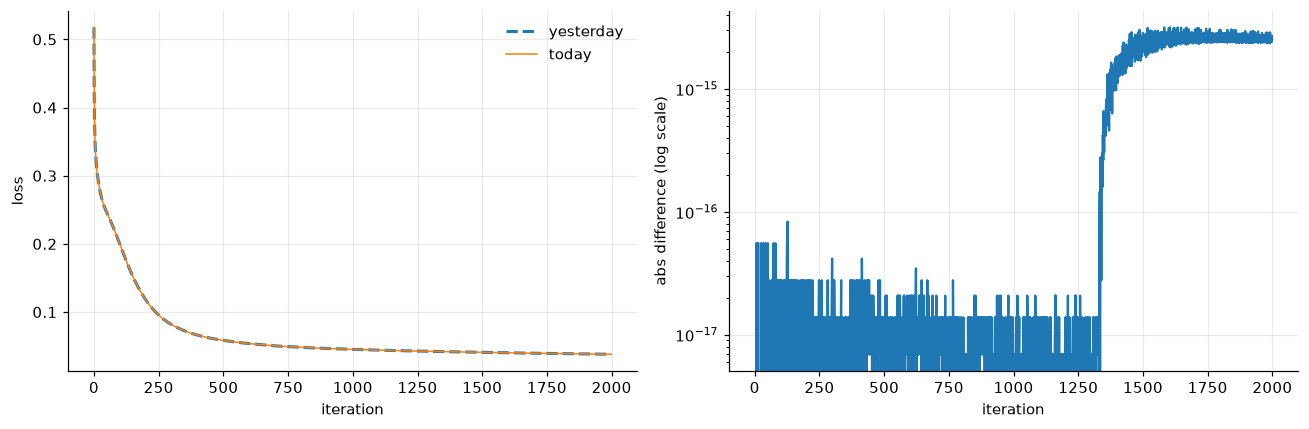

iteration      Wednesday         today
0           0.5176936977  0.5176936977
1           0.4208042200  0.4208042200
2           0.3845030030  0.3845030030

largest disagreement over 2,000 iterations: 3.17e-15
identical to six decimals: True


In [7]:
# ────────────────────────────────────────────────────────────────────
# 1) One figure, two lines: yesterday_losses and your torch_losses. Make one of
#    them dashed and thicker so an exact overlap is visible rather than hidden.
# 2) A second panel with the absolute difference per iteration, on a log y-axis.
#    A difference of 1e-15 does not show up on a linear scale.
# 3) Print the first three of each and the maximum absolute difference.
# Search: "matplotlib semilogy plot two curves difference"
# https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.semilogy.html
#
# ١) شكل واحد وخطّان: `yesterday_losses` و`torch_losses` عندك. واجعل أحدهما
#    متقطّعًا وأعرض ليكون التطابق التامّ مرئيًا لا مخفيًّا.
# ٢) لوحة ثانية بالفرق المطلق في كل تكرار على محور لوغاريتمي. فالفرق ‎1e-15 لا
#    يظهر على مقياس خطّي.
# ٣) اطبع أول ثلاثة من كلٍّ والفرق المطلق الأكبر.
# ابحث عن: "matplotlib semilogy plot two curves difference"
# ────────────────────────────────────────────────────────────────────

yesterday_losses = torch.tensor(yesterday_history["loss"].to_numpy())
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
# TODO: Plot both curves on the left panel and their absolute difference on the right.

# left panel: the two curves
axes[0].plot(yesterday_losses, label="yesterday", linestyle="--", linewidth=2)
axes[0].plot(torch_losses, label="today", linewidth=1)
axes[0].set_xlabel("iteration")
axes[0].set_ylabel("loss")
axes[0].legend()

# right panel: absolute difference, log scale
gap = (yesterday_losses - torch_losses).abs()
axes[1].semilogy(gap)
axes[1].set_xlabel("iteration")
axes[1].set_ylabel("abs difference (log scale)")

plt.tight_layout()
plt.show()
max_gap = (yesterday_losses - torch_losses).abs().max().item()
print(f"{'iteration':<10}{'Wednesday':>14}{'today':>14}")
for i in (0, 1, 2):
    print(f"{i:<10}{yesterday_losses[i]:>14.10f}{torch_losses[i]:>14.10f}")
print(f"\nlargest disagreement over {ITERATIONS:,} iterations: {max_gap:.2e}")
print(f"identical to six decimals: {max_gap < 5e-7}")

The two runs agree to about **1e-15**, which is the precision of `float64` itself. They are not
similar; they are the same computation, expressed twice.

That is worth being clear about, because it is the whole claim of the day. `nn.Linear`, `nn.BCELoss`
and `optim.SGD` did not use a better algorithm, a cleverer gradient or a smarter update. They did
exactly what your `forward`, your `bce_loss` and your `no_grad` update did on Wednesday, on the same
starting numbers, in the same order — and the only reason the agreement is this exact is that you
loaded your own initial weights instead of letting `nn.Linear` initialise its own.

Had you skipped that step, the two curves would have differed visibly from iteration 1, and you would
have spent the afternoon debugging a difference that was only initialisation. Which is the pitfall on
slide 62, and the reason `tensor_net_params.pt` exists.

<div dir="rtl" align="right">

يتوافق التشغيلان إلى نحو **1e-15**، وهي دقة `float64` نفسها. فهما ليسا متشابهين، بل هما الحساب نفسه
مكتوبًا مرتين.

وهذا يستحقّ الوضوح، فهو ادعاء اليوم كله. فلم تستخدم `nn.Linear` و`nn.BCELoss` و`optim.SGD` خوارزمية
أفضل ولا اشتقاقًا أذكى ولا تحديثًا أحكم. بل فعلت بالضبط ما فعلته `forward` و`bce_loss` وتحديثك داخل
`no_grad` يوم الأربعاء، على الأرقام الابتدائية نفسها وبالترتيب نفسه — والسبب الوحيد لهذه الدقة في
التوافق أنك حمّلت أوزانك الابتدائية بدل أن تدع `nn.Linear` يُهيّئ أوزانه.

ولو تخطّيت تلك الخطوة لاختلف المنحنيان اختلافًا مرئيًا من التكرار الأول، ولصرفت بعد الظهر في تصحيح
فرقٍ لم يكن إلا التهيئة. وهذا هو الفخّ في الشريحة ٦٢، وهو سبب وجود `tensor_net_params.pt`.

</div>


### Task 2.5 — count what changed

The last time a library replaced your code was Wednesday, and that one was real: autograd deleted a
hand-written backward pass. Today is different, and it is worth being honest about how.

Put yesterday's training code next to today's and count the lines. Then go down the table:
`nn.Linear` **renamed** your matmul and your initialisation, `torch.relu` **renamed**
`torch.clamp(z, min=0)`, `nn.BCELoss` **renamed** your `bce_loss`, `optimizer.step()` **renamed** your
`no_grad` update loop, `optimizer.zero_grad()` **renamed** `p.grad = None`, and `loss.backward()` is
the same line it was yesterday.

**Nothing in today's table is a removal.** What you bought is not fewer lines, it is named parts:
`model.parameters()` instead of a dict you maintain by hand, `state_dict()` to save it, `.to(device)`
to move it, and an optimiser you can swap for Adam by changing one word — which tomorrow does four
times.

<div dir="rtl" align="right">

### المهمة ٢٫٥ — عُدّ ما تغيّر

آخر مرة استبدلت فيها مكتبةٌ شيفرتك كانت يوم الأربعاء، وكانت حقيقية: فقد حذف الاشتقاق التلقائي مرورًا
خلفيًا مكتوبًا باليد. واليوم مختلف، ويستحقّ أن تكون صادقًا في كيفية اختلافه.

ضَع شيفرة تدريب الأمس بجانب شيفرة اليوم وعُدّ الأسطر. ثم انزل في الجدول: فـ `nn.Linear` **أعادت
تسمية** ضربك المصفوفي وتهيئتك، و`torch.relu` **أعادت تسمية** `torch.clamp(z, min=0)`، و`nn.BCELoss`
**أعادت تسمية** `bce_loss` عندك، و`optimizer.step()` **أعاد تسمية** حلقة تحديثك داخل `no_grad`،
و`optimizer.zero_grad()` **أعاد تسمية** `p.grad = None`، و`loss.backward()` هو السطر نفسه الذي كان
بالأمس.

**ولا شيء في جدول اليوم حذفٌ.** فالذي اشتريته ليس أسطرًا أقل بل أجزاء مُسمّاة: `model.parameters()`
بدل قاموس تحفظه بيدك، و`state_dict()` لحفظه، و`.to(device)` لنقله، ومُحسِّن تستبدله بـ Adam بتغيير
كلمة واحدة — وهذا ما يفعله الغد أربع مرات.

</div>


In [8]:
yesterday_code = """
def init_params(n_in, n_hidden, n_out, seed=SEED):
    generator = torch.Generator().manual_seed(seed)
    return {"W1": torch.randn(n_in, n_hidden, generator=generator) * math.sqrt(2 / n_in),
            "b1": torch.zeros(n_hidden),
            "W2": torch.randn(n_hidden, n_out, generator=generator) * math.sqrt(2 / n_hidden),
            "b2": torch.zeros(n_out)}

def forward(params, X):
    z1 = X @ params["W1"] + params["b1"]
    a1 = torch.clamp(z1, min=0)
    z2 = a1 @ params["W2"] + params["b2"]
    return 1 / (1 + torch.exp(-z2)), {"z1": z1, "a1": a1, "z2": z2}

def bce_loss(y_true, y_pred):
    p = torch.clamp(y_pred, 1e-12, 1 - 1e-12)
    return -torch.mean(y_true * torch.log(p) + (1 - y_true) * torch.log(1 - p))

for p in params.values():
    p.requires_grad_(True)
for iteration in range(ITERATIONS):
    output, _ = forward(params, X)
    loss = bce_loss(y, output)
    loss.backward()
    with torch.no_grad():
        for p in params.values():
            p -= LR * p.grad
            p.grad = None
"""

today_code = """
class Net(nn.Module):
    def __init__(self, n_in=N_IN, n_hidden=N_HIDDEN, n_out=N_OUT):
        super().__init__()
        self.fc1 = nn.Linear(n_in, n_hidden)
        self.fc2 = nn.Linear(n_hidden, n_out)

    def forward(self, x):
        return torch.sigmoid(self.fc2(torch.relu(self.fc1(x))))

model = Net()
optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.BCELoss()
for iteration in range(ITERATIONS):
    optimizer.zero_grad()
    output = model(X)
    loss = criterion(output, y)
    loss.backward()
    optimizer.step()
"""


def count(source):
    return len([line for line in source.strip().splitlines() if line.strip()])


print(f"Wednesday's network and training loop: {count(yesterday_code)} lines")
print(f"today's:                                {count(today_code)} lines")
print()
print(f"{'Wednesday':<40}{'today':<24}{'what changed'}")
print("-" * 82)
for wednesday, today, change in [
    ("z1 = X @ W1 + b1  (and init_params)", "nn.Linear(2, 8)", "renamed, and it inits"),
    ("torch.clamp(z1, min=0)", "torch.relu", "renamed"),
    ("bce_loss(y, output)", "nn.BCELoss()", "renamed"),
    ("p.requires_grad_(True), for every p", "(nothing)", "the layer does it"),
    ("loss.backward()", "loss.backward()", "nothing at all"),
    ("with no_grad: p -= LR * p.grad", "optimizer.step()", "renamed"),
    ("p.grad = None", "optimizer.zero_grad()", "renamed"),
]:
    print(f"{wednesday:<40}{today:<24}{change}")
print("\nthe one real removal happened on Wednesday: the backward pass you never wrote")

Wednesday's network and training loop: 24 lines
today's:                                16 lines

Wednesday                               today                   what changed
----------------------------------------------------------------------------------
z1 = X @ W1 + b1  (and init_params)     nn.Linear(2, 8)         renamed, and it inits
torch.clamp(z1, min=0)                  torch.relu              renamed
bce_loss(y, output)                     nn.BCELoss()            renamed
p.requires_grad_(True), for every p     (nothing)               the layer does it
loss.backward()                         loss.backward()         nothing at all
with no_grad: p -= LR * p.grad          optimizer.step()        renamed
p.grad = None                           optimizer.zero_grad()   renamed

the one real removal happened on Wednesday: the backward pass you never wrote


### Task 2.6 — break it on purpose

PyTorch **accumulates** gradients into `.grad` rather than replacing them. That is deliberate: it is
what lets you split one large batch across several backward passes. It also means that if you never
clear them, step 2 uses two gradients added together, step 10 uses ten, and the effective step size
grows every iteration. Yesterday you cleared them yourself with `p.grad = None`; today
`optimizer.zero_grad()` does it.

Remove `optimizer.zero_grad()`, train a fresh copy of the model for 100 iterations, and plot the loss
beside a correct 100-iteration run.

Then put the line back. This is the most common PyTorch bug there is, it raises no error, and the
curve it produces — fine for a while, then away — is now something you can recognise on sight.

<div dir="rtl" align="right">

### المهمة ٢٫٦ — اكسِرها عن قصد

يُراكم PyTorch الاشتقاقات في `.grad` ولا يستبدلها. وهذا مقصود: فهو ما يتيح لك تقسيم دفعة كبيرة على
عدة مرورات خلفية. ويعني أيضًا أنك إن لم تمسحها استخدمت الخطوة الثانية اشتقاقين مجموعين، والخطوة
العاشرة عشرة، فيكبر حجم الخطوة الفعلي في كل تكرار. وبالأمس مسحتها بنفسك بـ `p.grad = None`، واليوم
يفعل ذلك `optimizer.zero_grad()`.

احذف `optimizer.zero_grad()`، ودرّب نسخة جديدة من النموذج مئة تكرار، وارسم الخسارة بجانب تشغيل صحيح من
مئة تكرار.

ثم أعِد السطر. فهذا أشيع عيب في PyTorch، ولا يُخرِج خطأً، والمنحنى الذي يُنتجه — سليم لفترة ثم ابتعاد —
صار شيئًا تعرفه من النظرة الأولى.

</div>


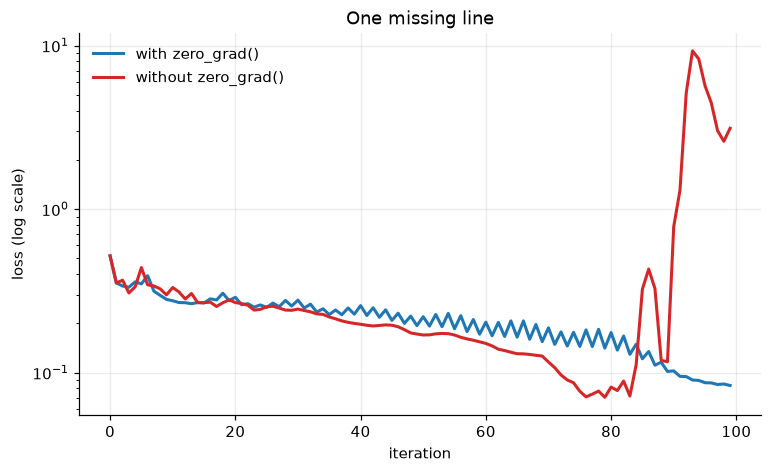

with zero_grad:    0.5177 -> 0.0835
without zero_grad: 0.5177 -> 3.1199   (lowest 0.0707, highest 9.2837 at iteration 93)
the broken run's final loss is 37.4x the correct one's


In [9]:
# ────────────────────────────────────────────────────────────────────
# 1) Write one function that trains a fresh model for n iterations and returns
#    the losses, with a flag saying whether to call zero_grad. Fresh means loading
#    the saved initial weights again — both runs must start in the same place.
# 2) Run it twice, 100 iterations each, with the flag on and off.
# 3) Plot both on a log y-axis. The broken one leaves the visible range fast.
# Search: "pytorch zero_grad gradient accumulation exploding loss"
# https://pytorch.org/docs/stable/generated/torch.optim.Optimizer.zero_grad.html
#
# ١) اكتب دالة واحدة تدرّب نموذجًا جديدًا عددًا من التكرارات وتُرجع الخسائر، مع
#    راية تقول هل تنادي `zero_grad`. و«جديد» تعني إعادة تحميل الأوزان الابتدائية
#    المحفوظة — فعلى التشغيلين أن يبدآ من الموضع نفسه.
# ٢) شغّلها مرتين، مئة تكرار لكل منهما، بالراية مفعّلة ثم مُطفأة.
# ٣) ارسم الاثنين على محور لوغاريتمي. فالمعطوب يغادر المدى المرئي بسرعة.
# ابحث عن: "pytorch zero_grad gradient accumulation exploding loss"
# ────────────────────────────────────────────────────────────────────

BREAK_LR = 4 * LR   # see the note below the plot
BREAK_ITERATIONS = 100
def fresh_model():
    """A new model loaded with yesterday's starting weights. Both runs start here."""
    m = Net()
    with torch.no_grad():
        m.fc1.weight.copy_(INIT["W1"].T)
        m.fc1.bias.copy_(INIT["b1"])
        m.fc2.weight.copy_(INIT["W2"].T)
        m.fc2.bias.copy_(INIT["b2"])
    return m
# TODO: Write train_briefly(iterations, zero_grad=True, lr=BREAK_LR) -> losses.

def train_briefly(iterations, zero_grad=True, lr=BREAK_LR):
    model = fresh_model()
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.BCELoss()

    losses = []
    for _ in range(iterations):
        if zero_grad:
            optimizer.zero_grad()

        y_pred = model(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()

        losses.append(loss.item())

    return torch.tensor(losses)

# Run both experiments
correct_run = train_briefly(BREAK_ITERATIONS, zero_grad=True)
broken_run  = train_briefly(BREAK_ITERATIONS, zero_grad=False)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.semilogy(correct_run, color=PALETTE[0], linewidth=2, label="with zero_grad()")
ax.semilogy(broken_run, color=PALETTE[3], linewidth=2,
            label="without zero_grad()")
ax.set_xlabel("iteration")
ax.set_ylabel("loss (log scale)")
ax.set_title("One missing line")
ax.legend()
plt.show()
print(f"with zero_grad:    {correct_run[0]:.4f} -> {correct_run[-1]:.4f}")
print(f"without zero_grad: {broken_run[0]:.4f} -> {broken_run[-1]:.4f}   "
      f"(lowest {broken_run.min():.4f}, highest {broken_run.max():.4f} "
      f"at iteration {int(broken_run.argmax())})")
print(f"the broken run's final loss is "
      f"{broken_run[-1] / correct_run[-1]:.1f}x the correct one's")

Fine, and then away. For most of the run the broken curve looks healthy — better than healthy: it
falls **faster** than the correct one, because a gradient that has been added to itself is simply a
bigger step. Then, near iteration 90, it leaves. It peaks around 9 and ends dozens of times worse than
the correct run, from removing a single line that raised no error.

Two notes on how this was set up, because both matter more than the picture.

**The learning rate here is four times the one you have been using.** At `lr=1.0` on a problem this
small, the accumulated gradient behaves like a bigger step for the whole 100 iterations, and the broken
run actually ends *better* than the correct one — which is exactly what makes this bug dangerous. It
does not always look like a disaster; it looks like a run that trained oddly, or even well.
Quadrupling the rate makes the mechanism visible inside 100 iterations.

**The effective step size grows every iteration.** Step 1 uses one gradient, step 2 uses two added
together, step 90 uses ninety. So the early iterations look normal and the damage compounds — which is
why the curve falls first and diverges later, rather than being wrong from the start.

<div dir="rtl" align="right">

سليم، ثم ابتعاد. ففي أغلب التشغيل يبدو المنحنى المعطوب معافى — بل أكثر من معافى: إذ يهبط **أسرع** من
الصحيح، لأن الاشتقاق المُضاف إلى نفسه ليس إلا خطوة أكبر. ثم قرب التكرار التسعين يبتعد. فيبلغ ذروته عند
نحو ٩ وينتهي أسوأ من التشغيل الصحيح بعشرات الأضعاف، بحذف سطر واحد لم يُخرِج خطأً.

وملاحظتان على طريقة الإعداد، وكلتاهما أهمّ من الصورة.

**معدّل التعلّم هنا أربعة أضعاف الذي كنت تستخدمه.** فعند `lr=1.0` على مسألة بهذا الصغر يتصرّف الاشتقاق
المتراكم كخطوة أكبر طوال التكرارات المئة، وينتهي التشغيل المعطوب فعلًا **أفضل** من الصحيح — وهذا بالضبط
ما يجعل هذا العيب خطِرًا. فهو لا يبدو كارثة دائمًا، بل يبدو تشغيلًا تدرّب على نحو غريب، أو حتى جيد.
ومضاعفة المعدّل أربع مرات تُظهر الآلية داخل مئة تكرار.

**وحجم الخطوة الفعلي يكبر في كل تكرار.** فالخطوة الأولى تستخدم اشتقاقًا واحدًا، والثانية اثنين
مجموعين، والتسعون تسعين. فتبدو التكرارات الأولى عادية ويتراكم الضرر — ولهذا يهبط المنحنى أولًا ثم
يبتعد، بدل أن يكون خطأً من البداية.

</div>


**Your sentence:** _(what accumulated, and why does the damage grow with every iteration rather than
staying constant?)_

<div dir="rtl" align="right">

**جملتك:** _(ما الذي تراكم، ولماذا يكبر الضرر مع كل تكرار بدل أن يبقى ثابتًا؟)_

</div>


## Section 3 — Stretch: mini-batches, and the fused loss  (≈30 min)

Open-ended. Lower expectation of completeness.

Two things, and the first one produces today's artefact.

**Mini-batches.** Train the same network through the `DataLoader` from task 2.1 — 32 rows per step,
shuffled, on a proper train/validation split — and record both losses per epoch. The curve is noisier
than the full-batch one and it gets there in far fewer passes over the data, which is Sunday's whole
first section arriving early.

**`BCEWithLogitsLoss`.** Remove the sigmoid from the model's output and use
`nn.BCEWithLogitsLoss` instead of `nn.BCELoss`. Mathematically it is the same loss; numerically it is
safer, because it computes the sigmoid and the logarithm together and never forms a probability that
could round to exactly 0 or 1. This is why every serious PyTorch codebase uses it, and why models you
read will often have no activation on their final layer.

<div dir="rtl" align="right">

## القسم الثالث — الإضافي: الدفعات المصغّرة والخسارة المدموجة (نحو ٣٠ دقيقة)

مفتوح. والتوقّع في الإكمال أقل.

أمران، والأول يُنتج أثر اليوم.

**الدفعات المصغّرة.** درّب الشبكة نفسها عبر `DataLoader` من المهمة ٢٫١ — ٣٢ صفًا في الخطوة، مخلوطة،
على تقسيم تدريب وتحقّق حقيقي — وسجّل الخسارتين في كل حقبة. والمنحنى أكثر ضوضاءً من منحنى الدفعة
الكاملة ويصل بعدد مرورات أقل بكثير على البيانات، وهذا هو القسم الأول من يوم الأحد كله وقد وصل مبكرًا.

**`BCEWithLogitsLoss`.** احذف الدالة السينية من مَخرج النموذج واستخدم `nn.BCEWithLogitsLoss` بدلًا من
`nn.BCELoss`. وهي رياضيًا الخسارة نفسها، وعدديًا أأمن، لأنها تحسب الدالة السينية واللوغاريتم معًا ولا
تُكوّن احتمالًا قد يُقرَّب إلى صفر أو واحد تامّ. ولهذا تستخدمها كل شيفرة PyTorch جادّة، ولهذا كثير من
النماذج التي تقرؤها لا تحمل دالة تنشيط على طبقتها الأخيرة.

</div>


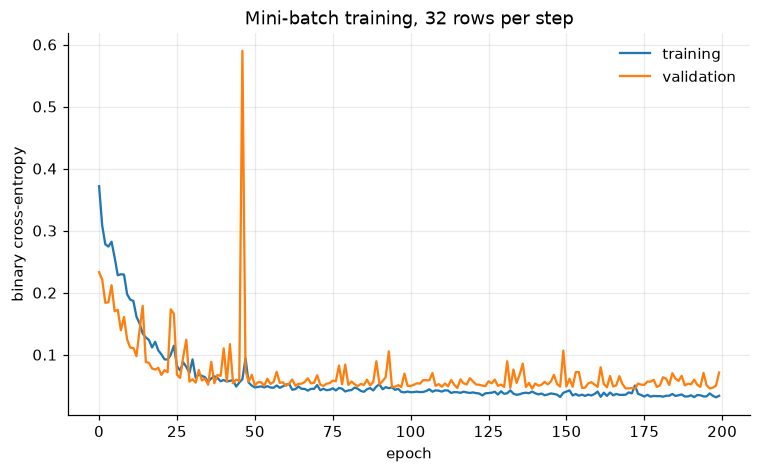

after 200 epochs (2,600 steps): train 0.0337, validation 0.0712, val accuracy 0.970


In [10]:
# ────────────────────────────────────────────────────────────────────
# 1) Split the rows 400/100 before building the loaders, and shuffle only the
#    training one — a shuffled evaluation loader makes your reported number move
#    between runs for no reason.
# 2) One epoch = one pass over the training loader. Inside it, the same five
#    lines. After it, evaluate under torch.no_grad() and model.eval().
# 3) Record epoch, train loss and val loss. 200 epochs is a few seconds here.
# Search: "pytorch train validation loop no_grad eval mode"
# https://pytorch.org/tutorials/beginner/basics/optimization_tutorial.html
#
# ١) قسّم الصفوف ٤٠٠/١٠٠ قبل بناء المُحمّلين، واخلط التدريب وحده — فمُحمّل تقييم
#    مخلوط يجعل رقمك المعروض يتحرّك بين التشغيلات بلا سبب.
# ٢) الحقبة الواحدة مرور واحد على مُحمّل التدريب. وداخلها الأسطر الخمسة نفسها.
#    وبعدها قيّم داخل `torch.no_grad()` وفي وضع `model.eval()`.
# ٣) سجّل الحقبة وخسارة التدريب وخسارة التحقّق. ومئتا حقبة هنا بضع
#    ثوانٍ.
# ابحث عن: "pytorch train validation loop no_grad eval mode"
# ────────────────────────────────────────────────────────────────────

EPOCHS = 200
perm = torch.randperm(len(X), generator=torch.Generator().manual_seed(42))
train_idx, val_idx = perm[:400], perm[400:]
X_train, y_train = X[train_idx], y[train_idx]
X_val, y_val = X[val_idx], y[val_idx]
# TODO: Build a shuffled training loader and train for EPOCHS, recording both losses.

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=BATCH_SIZE,
    shuffle=True,
    generator=torch.Generator().manual_seed(42)
)

val_loader = DataLoader(
    TensorDataset(X_val, y_val),
    batch_size=BATCH_SIZE,
    shuffle=False
)

model = Net()
with torch.no_grad():
    model.fc1.weight.copy_(INIT["W1"].T)
    model.fc1.bias.copy_(INIT["b1"])
    model.fc2.weight.copy_(INIT["W2"].T)
    model.fc2.bias.copy_(INIT["b2"])

optimizer = torch.optim.SGD(model.parameters(), lr=LR)
criterion = nn.BCELoss()

records = []

for epoch in range(EPOCHS):
    model.train()
    train_losses = []

    # one epoch = one full pass over the training loader
    for xb, yb in train_loader:
        optimizer.zero_grad()
        y_pred = model(xb)
        loss = criterion(y_pred, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

    train_loss = sum(train_losses) / len(train_losses)

    # validation
    model.eval()
    with torch.no_grad():
        val_losses = []
        correct = 0
        total = 0

        for xb, yb in val_loader:
            y_pred = model(xb)
            val_losses.append(criterion(y_pred, yb).item())
            correct += ((y_pred > 0.5) == yb).sum().item()
            total += len(yb)

        val_loss = sum(val_losses) / len(val_losses)
        val_accuracy = correct / total

    records.append({
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_loss,
        "val_accuracy": val_accuracy
    })

torch_history = pd.DataFrame(records)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(torch_history["epoch"], torch_history["train_loss"],
        color=PALETTE[0], label="training")
ax.plot(torch_history["epoch"], torch_history["val_loss"],
        color=PALETTE[1], label="validation")
ax.set_xlabel("epoch")
ax.set_ylabel("binary cross-entropy")
ax.set_title(f"Mini-batch training, {BATCH_SIZE} rows per step")
ax.legend()
plt.show()
print(f"after {EPOCHS} epochs ({EPOCHS * len(train_loader):,} steps): "
      f"train {torch_history.iloc[-1]['train_loss']:.4f}, "
      f"validation {torch_history.iloc[-1]['val_loss']:.4f}, "
      f"val accuracy {torch_history.iloc[-1]['val_accuracy']:.3f}")

In [11]:
# ────────────────────────────────────────────────────────────────────
# 1) Build the same network without the final sigmoid — return the logit.
# 2) Train it with nn.BCEWithLogitsLoss for a few hundred iterations, then apply
#    a sigmoid to its output by hand and compare the predictions with the
#    sigmoid+BCELoss model's.
# 3) Then check model.eval() changes nothing here — there is no dropout and no
#    batch norm yet, so this is the control case for Sunday.
# Search: "pytorch BCEWithLogitsLoss numerically stable log-sum-exp"
# https://pytorch.org/docs/stable/generated/torch.nn.BCEWithLogitsLoss.html
#
# ١) ابنِ الشبكة نفسها بلا الدالة السينية الأخيرة — وأرجِع الـ logit.
# ٢) درّبها بـ `nn.BCEWithLogitsLoss` بضع مئات من التكرارات، ثم طبّق الدالة
#    السينية على مُخرَجها يدويًا وقارن التنبّؤات بتنبّؤات نموذج السينية مع
#    `BCELoss`.
# ٣) ثم تحقّق أن `model.eval()` لا يغيّر شيئًا هنا — فلا Dropout ولا تطبيع دفعات
#    بعد، وهذه هي الحالة الضابطة ليوم الأحد.
# ابحث عن: "pytorch BCEWithLogitsLoss numerically stable log-sum-exp"
# ────────────────────────────────────────────────────────────────────

# TODO: Train a logit-output model with BCEWithLogitsLoss and compare it with the sigmoid + BCELoss model after 300 identical steps.

class LogitNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(2, 8)
        self.fc2 = nn.Linear(8, 1)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        return self.fc2(x)   # ← لا يوجد sigmoid هنا، نرجع logit فقط

def fresh_logit_model():
    m = LogitNet()
    with torch.no_grad():
        m.fc1.weight.copy_(INIT["W1"].T)
        m.fc1.bias.copy_(INIT["b1"])
        m.fc2.weight.copy_(INIT["W2"].T)
        m.fc2.bias.copy_(INIT["b2"])
    return m

# Train fused (logit + BCEWithLogitsLoss)
fused_model = fresh_logit_model()
optimizer_fused = torch.optim.SGD(fused_model.parameters(), lr=LR)
criterion_fused = nn.BCEWithLogitsLoss()

for _ in range(300):
    optimizer_fused.zero_grad()
    logits = fused_model(X)
    loss = criterion_fused(logits, y)
    loss.backward()
    optimizer_fused.step()

# Train plain (sigmoid + BCELoss)
plain_model = fresh_model()   # نفس Net السابقة مع sigmoid
optimizer_plain = torch.optim.SGD(plain_model.parameters(), lr=LR)
criterion_plain = nn.BCELoss()

for _ in range(300):
    optimizer_plain.zero_grad()
    probs = plain_model(X)
    loss = criterion_plain(probs, y)
    loss.backward()
    optimizer_plain.step()

# Compare predictions
with torch.no_grad():
    fused_probs = torch.sigmoid(fused_model(X))
    plain_probs = plain_model(X)
    fused_vs_plain = (fused_probs - plain_probs).abs().max().item()

# Check eval() changes nothing
plain_model.eval()
with torch.no_grad():
    before = plain_model(X)
    after = plain_model(X)
    eval_unchanged = torch.allclose(before, after)

print(f"largest difference between the fused and the plain model: "
      f"{fused_vs_plain:.2e}")
print(f"the same model, and the fused one never forms a probability at all")
print(f"\nmodel.eval() changed the predictions: {not eval_unchanged}")
print(f"— no dropout and no batch norm yet, so it cannot. On Sunday it will.")

largest difference between the fused and the plain model: 9.99e-16
the same model, and the fused one never forms a probability at all

model.eval() changed the predictions: False
— no dropout and no batch norm yet, so it cannot. On Sunday it will.


**Your two sentences:** _(why is computing the sigmoid and the logarithm together safer than computing
them one after the other? And what would you have to add to the model before `eval()` starts
mattering?)_

<div dir="rtl" align="right">

**جملتاك:** _(لماذا يكون حساب الدالة السينية واللوغاريتم معًا أأمن من حسابهما واحدًا بعد الآخر؟ وما
الذي عليك إضافته إلى النموذج قبل أن يبدأ `eval()` بالتأثير؟)_

</div>


## Save your artefact

`torch_net_history.parquet` — one row per epoch of the mini-batch run: the epoch number, the training
loss, the validation loss and the validation accuracy.

Note what changed about the shape of this file compared with yesterday's. Yesterday you recorded a
single loss per iteration, because there was only one thing to record. Today there are **two** curves,
because there is a held-out set — and tomorrow's entire lab is about reading the gap between them.

<div dir="rtl" align="right">

## احفظ مخرجاتك

`torch_net_history.parquet` وفيه صف لكل حقبة من تشغيل الدفعات المصغّرة: رقم الحقبة، وخسارة التدريب،
وخسارة التحقّق، ودقة التحقّق.

ولاحظ ما تغيّر في شكل هذا الملف مقارنةً بملف الأمس. فقد سجّلت بالأمس خسارة واحدة لكل تكرار لأنه لم
يكن ثمّة إلا شيء واحد يُسجَّل. واليوم منحنيان لأن ثمّة مجموعة محجوزة — ومعمل الغد كله عن قراءة الفجوة
بينهما.

</div>


In [12]:
out = ARTEFACT_DIR / "torch_net_history.parquet"
torch_history.to_parquet(out, index=False)

reloaded = pd.read_parquet(out)
print(f"Saved {out}")
print(f"{len(reloaded)} epochs, columns {list(reloaded.columns)}")
print(f"train loss {reloaded.iloc[0]['train_loss']:.4f} -> "
      f"{reloaded.iloc[-1]['train_loss']:.4f}")
print(f"val   loss {reloaded.iloc[0]['val_loss']:.4f} -> "
      f"{reloaded.iloc[-1]['val_loss']:.4f}")
best_epoch = int(reloaded['val_loss'].idxmin())
print(f"\nbest validation loss was {reloaded['val_loss'].min():.4f} at epoch {best_epoch}, "
      f"and the last epoch scored {reloaded.iloc[-1]['val_loss']:.4f}")
print(f"keep that pair in mind — it is tomorrow's early-stopping task in one line")

Saved c:\Users\Fajer\OneDrive\Documents\GitHub\AIEP_Olo_student\week_3_neural_networks\labs\D4_pytorch\artefacts\torch_net_history.parquet
200 epochs, columns ['epoch', 'train_loss', 'val_loss', 'val_accuracy']
train loss 0.3716 -> 0.0337
val   loss 0.2331 -> 0.0712

best validation loss was 0.0453 at epoch 172, and the last epoch scored 0.0712
keep that pair in mind — it is tomorrow's early-stopping task in one line


## Sanity check

Run this last. Every check that fails tells you what to fix and why.

The first one is the day's claim in a single assertion: a library you never taught anything printed
the gradient you computed by hand on Wednesday — this time on a layer it built itself.

<div dir="rtl" align="right">

## فحص النتائج

شغّل هذه الخليّة أخيرًا. كل فحص يفشل يخبرك بما تُصلحه ولماذا.

والفحص الأول هو ادعاء اليوم في تحقّق واحد: مكتبة لم تُعلّمها شيئًا طبعت الاشتقاق الذي حسبته بيدك يوم
الأربعاء — وهذه المرة على طبقة بنتها بنفسها.

</div>


In [13]:
# --- Sanity checks ----------------------------------------------------------------

check(torch.allclose(W2_grad, torch.tensor([[-0.1360, -0.0544]]), atol=5e-5),
      f"loss.backward() on the layer-built lecture network must reproduce Wednesday's "
      f"gradients [-0.1360, -0.0544] to four decimals — it produced "
      f"{W2_grad.round(decimals=6).tolist()}",
      f"يجب أن يُعيد `loss.backward()` على شبكة المحاضرة المبنيّة من طبقات إنتاج اشتقاقَي "
      f"الأربعاء `[-0.1360, -0.0544]` إلى أربع خانات عشرية — والناتج "
      f"{W2_grad.round(decimals=6).tolist()}")

check(batch_shapes[0] == (32, 2) and batch_shapes[-1] == (20, 2),
      f"a full DataLoader batch must be (32, 2) and the last one (20, 2) — got "
      f"{batch_shapes[0]} and {batch_shapes[-1]}. 500 rows do not divide into 32.",
      f"يجب أن تكون الدفعة الكاملة `(32, 2)` والأخيرة `(20, 2)` — والناتج "
      f"{batch_shapes[0]} و{batch_shapes[-1]}. فـ ٥٠٠ صف لا تقبل القسمة على ٣٢.")

check(n_parameters == 33,
      f"the model must hold 33 parameters — 24 weights and 9 biases, the count you made "
      f"by hand on Tuesday — and it holds {n_parameters}",
      f"يجب أن يحمل النموذج ٣٣ معاملًا — ٢٤ وزنًا و٩ انحيازات، وهو العدد الذي عددته بيدك "
      f"يوم الثلاثاء — والموجود {n_parameters}")

check(max_gap < 1e-6,
      f"with the same starting weights and the same settings, nn.Module + optim.SGD must "
      f"reproduce Wednesday's loss curve to six decimals — the largest disagreement over "
      f"{ITERATIONS:,} iterations was {max_gap:.2e}",
      f"بالأوزان الابتدائية نفسها والإعدادات نفسها، يجب أن يُعيد `nn.Module` مع `optim.SGD` "
      f"إنتاج منحنى خسارة الأربعاء إلى ست خانات عشرية — وأكبر اختلاف عبر {ITERATIONS:,} تكرار "
      f"كان {max_gap:.2e}")

yesterday_accuracy = float(yesterday_history.iloc[-1]["accuracy"])
check(abs(torch_accuracy - yesterday_accuracy) < 0.03,
      f"today's final accuracy must be within 3 points of Wednesday's — "
      f"{torch_accuracy:.3f} vs {yesterday_accuracy:.3f}",
      f"يجب أن تكون دقة اليوم النهائية في حدود ٣ نقاط من دقة الأربعاء — "
      f"{torch_accuracy:.3f} مقابل {yesterday_accuracy:.3f}")

check(bool(broken_run[-1] > correct_run[-1]),
      f"the run without zero_grad() must end WORSE than the correct one at lr={BREAK_LR} "
      f"— broken {broken_run[-1]:.4f} vs correct {correct_run[-1]:.4f}. If it did not, "
      f"check that you actually skipped the call rather than moving it.",
      f"يجب أن ينتهي التشغيل بلا `zero_grad()` **أسوأ** من الصحيح — المعطوب "
      f"{broken_run[-1]:.4f} مقابل الصحيح {correct_run[-1]:.4f}. فإن لم يكن كذلك فتحقّق "
      f"أنك حذفت النداء فعلًا ولم تنقله فقط.")

check(out.exists() and len(reloaded) == EPOCHS
      and {"train_loss", "val_loss"} <= set(reloaded.columns),
      f"torch_net_history.parquet must record {EPOCHS} epochs with both losses — it has "
      f"{len(reloaded)} rows and the columns {list(reloaded.columns)}",
      f"يجب أن يسجّل `torch_net_history.parquet` عدد {EPOCHS} حقبة بالخسارتين — وفيه "
      f"{len(reloaded)} صفًا والأعمدة {list(reloaded.columns)}")

report()

──────────────────────────────────────────────────────────────────
  ✓  loss.backward() on the layer-built lecture network must reproduce Wednesday's gradients [-0.1360, -0.0544] to four decimals — it produced [[-0.136041, -0.054416]]
  ✓  a full DataLoader batch must be (32, 2) and the last one (20, 2) — got torch.Size([32, 2]) and torch.Size([20, 2]). 500 rows do not divide into 32.
  ✓  the model must hold 33 parameters — 24 weights and 9 biases, the count you made by hand on Tuesday — and it holds 33
  ✓  with the same starting weights and the same settings, nn.Module + optim.SGD must reproduce Wednesday's loss curve to six decimals — the largest disagreement over 2,000 iterations was 3.17e-15
  ✓  today's final accuracy must be within 3 points of Wednesday's — 0.986 vs 0.986
  ✓  the run without zero_grad() must end WORSE than the correct one at lr=4.0 — broken 3.1199 vs correct 0.0835. If it did not, check that you actually skipped the call rather than moving it.
  ✓  torch_net_h

## What's next

You have written the same network three ways this week — arithmetic on tensors, then autograd, then
layers and an optimiser — and proved each one is the same computation as the last. From here you use
the library, and you use it knowing exactly what each part of it replaced.

Tomorrow (**W3D5**) the data changes for the first time since Tuesday: **MNIST**, 28×28 images of
handwritten digits, loaded with `torchvision`. Ten classes instead of two, 784 pixels instead of two
coordinates, and the same five lines. Then the week's reckoning, in two halves. First, diagnosis: four
loss curves, four different faults, and the vocabulary for naming them — a learning rate too high, a
learning rate too low, overfitting, and a model that learned nothing and says so with `ln 10`. Then
dropout, optimisers, batch norm and early stopping, measured rather than described — and your best
network against the kind of boosted tree that won on Monday's table, this time on pixels.

Two things travel with you:

- **The five lines.** Every model in weeks 4 to 7 is trained by them, unchanged.
- **`torch_net_history.parquet`** — the first file you have with a training curve *and* a validation
  curve. Tomorrow is about the gap between them.

**A3 is due W4D2.** Today's loop is what you will train it with.

<div dir="rtl" align="right">

## ماذا بعد

كتبت الشبكة نفسها بثلاث طرق هذا الأسبوع — حسابًا على التنسورات، ثم بالاشتقاق التلقائي، ثم طبقاتٍ
ومُحسِّنًا — وأثبتّ أن كل طريقة هي الحساب نفسه الذي سبقها. ومن هنا تستخدم المكتبة، وتستخدمها وأنت تعرف
بالضبط ما الذي حلّ محلّه كل جزء منها.

وغدًا (**الأسبوع ٣ اليوم ٥**) تتغيّر البيانات لأول مرة منذ الثلاثاء: **MNIST**، صور بحجم ٢٨×٢٨ لأرقام
مكتوبة بخط اليد، تُحمَّل بـ `torchvision`. عشر فئات بدل اثنتين، و٧٨٤ بكسلًا بدل إحداثيين، والأسطر الخمسة
نفسها. ثم حساب الأسبوع في نصفين. أولًا التشخيص: أربعة منحنيات خسارة وأربعة أعطال مختلفة، والمفردات التي
تسمّيها بها — معدّل تعلّم مرتفع، ومعدّل منخفض، وفرط مطابقة، ونموذج لم يتعلّم شيئًا ويقول ذلك بـ
`ln 10`. ثم Dropout والمُحسِّنات وتطبيع الدفعات والإيقاف المبكر، مقيسةً لا موصوفة — وأفضل شبكة عندك
مقابل نوع الشجرة المعزَّزة الذي فاز على جدول الاثنين، وهذه المرة على البكسلات.

وشيئان يسافران معك:

- **الأسطر الخمسة.** فكل نموذج في الأسابيع من الرابع إلى السابع يُدرَّب بها بلا تغيير.
- **`torch_net_history.parquet`** وهو أول ملف عندك فيه منحنى تدريب **ومنحنى تحقّق**. والغد عن الفجوة
  بينهما.

**ويُسلَّم التكليف الثالث في الأسبوع الرابع اليوم الثاني.** وحلقة اليوم هي ما تدرّبه بها.

</div>
